# Notebook 02: Value-at-Risk (VaR) Methods Comparison

This notebook implements and compares three fundamental VaR methodologies:

1. **Parametric VaR** (Variance-Covariance) - Assumes normal distribution
2. **Historical Simulation VaR** - Uses empirical distribution
3. **Monte Carlo Simulation VaR** - Generates simulated paths

For each method, we calculate:
- 1-day 99% VaR
- 10-day 99% VaR (using square-root-of-time scaling)

---

## 2.1 Setup and Data Loading

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Statistical
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load configuration
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

CONFIDENCE = config['var_params']['confidence_var']  # 0.99
SIMULATIONS = config['var_params']['simulations']    # 10000
HOLDING_PERIODS = config['var_params']['holding_period_days']  # [1, 10]

TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']
TEST_START = config['dates']['test_start']
TEST_END = config['dates']['test_end']

print(f"VaR Confidence Level: {CONFIDENCE*100:.0f}%")
print(f"Monte Carlo Simulations: {SIMULATIONS:,}")

VaR Confidence Level: 99%
Monte Carlo Simulations: 10,000


In [4]:
# Load prepared data from Notebook 01
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']
asset_returns = pd.read_csv('../outputs/asset_returns.csv', index_col=0, parse_dates=True)

# Split into train/test
train_returns = portfolio_returns[TRAIN_START:TRAIN_END]
test_returns = portfolio_returns[TEST_START:TEST_END]

print(f"Training period: {len(train_returns)} days")
print(f"Testing period: {len(test_returns)} days")

Training period: 731 days
Testing period: 249 days


## 2.2 Parametric VaR (Variance-Covariance Method)

### Theory

The parametric approach assumes returns follow a normal distribution. Under this assumption:

$$VaR_{\alpha} = \mu + z_{\alpha} \times \sigma$$

Where:
- $\mu$ = mean of returns
- $\sigma$ = standard deviation of returns  
- $z_{\alpha}$ = z-score for confidence level (2.326 for 99%)

### Advantages
- Computationally simple and fast
- Easy to interpret and explain
- Works well when returns are approximately normal

### Limitations
- Assumes normal distribution (underestimates tail risk)
- Does not capture fat tails or skewness

In [5]:
def parametric_var(returns, confidence=0.99):
    """
    Calculate Parametric (Variance-Covariance) VaR.
    
    The parametric approach assumes returns follow a normal distribution.
    VaR is calculated as: VaR = μ + z_α × σ
    
    Parameters:
    -----------
    returns : pd.Series
        Historical returns
    confidence : float
        Confidence level (e.g., 0.99 for 99%)
        
    Returns:
    --------
    tuple
        (VaR as negative number, mean, std)
    """
    # Step 1: Calculate mean (μ) - expected daily return
    mu = returns.mean()
    
    # Step 2: Calculate standard deviation (σ) - daily volatility
    sigma = returns.std()
    
    # Step 3: Get z-score for left tail at (1-confidence) percentile
    # For 99% confidence: z = norm.ppf(0.01) = -2.326
    # This is the number of standard deviations for the left tail cutoff
    z_score = norm.ppf(1 - confidence)
    
    # Step 4: Calculate VaR using the formula: VaR = μ + z × σ
    # Result is negative because z_score is negative (left tail)
    # Example: if μ=0.001, σ=0.02, z=-2.326
    #          VaR = 0.001 + (-2.326) × 0.02 = -0.0455 (4.55% loss)
    var = mu + z_score * sigma
    
    return var, mu, sigma

# Calculate Parametric VaR
param_var_1d, mu, sigma = parametric_var(train_returns, CONFIDENCE)

# 10-day VaR using square-root-of-time rule
# For multi-day VaR under i.i.d. assumption:
#   - Mean scales linearly: μ_10d = μ × 10
#   - Volatility scales by sqrt(T): σ_10d = σ × √10
#   - VaR_10d = μ × 10 + z × σ × √10
param_var_10d = mu * 10 + norm.ppf(1 - CONFIDENCE) * sigma * np.sqrt(10)

print(f"Parametric VaR Results (Training Period)")
print(f"="*50)
print(f"Mean daily return (μ): {mu:.4%}")
print(f"Daily volatility (σ): {sigma:.4%}")
print(f"Z-score (99%): {norm.ppf(1 - CONFIDENCE):.4f}")
print(f"")
print(f"1-Day 99% VaR: {param_var_1d:.4%} ({abs(param_var_1d):.4%} potential loss)")
print(f"10-Day 99% VaR: {param_var_10d:.4%} ({abs(param_var_10d):.4%} potential loss)")

Parametric VaR Results (Training Period)
Mean daily return (μ): 0.0643%
Daily volatility (σ): 1.9242%
Z-score (99%): -2.3263

1-Day 99% VaR: -4.4121% (4.4121% potential loss)
10-Day 99% VaR: -13.5123% (13.5123% potential loss)


## 2.3 Historical Simulation VaR

### Theory

Historical Simulation uses the actual empirical distribution of past returns without assuming any parametric form. The VaR is simply the percentile of historical returns:

$$VaR_{\alpha} = Percentile(returns, (1-\alpha) \times 100)$$

For 99% VaR, we find the 1st percentile of historical returns.

### Advantages
- No distributional assumptions
- Captures fat tails naturally
- Easy to understand and implement

### Limitations
- Assumes past is representative of future
- Limited by available historical data
- May miss extreme events not in the sample

In [6]:
def historical_var(returns, confidence=0.99):
    """
    Calculate Historical Simulation VaR.
    
    Uses empirical distribution - no distributional assumptions.
    VaR = percentile of historical returns at (1-confidence) level.
    
    Parameters:
    -----------
    returns : pd.Series
        Historical returns
    confidence : float
        Confidence level (e.g., 0.99 for 99%)
        
    Returns:
    --------
    float
        VaR as a negative number (potential loss)
    """
    # For 99% confidence, we want the 1st percentile (worst 1% of returns)
    # np.percentile(returns, 1) gives the value below which 1% of data falls
    # This naturally captures fat tails without assuming normal distribution
    percentile_level = (1 - confidence) * 100  # Convert to percentage (e.g., 1 for 99%)
    var = np.percentile(returns, percentile_level)
    return var

# Calculate Historical VaR
hist_var_1d = historical_var(train_returns, CONFIDENCE)

# 10-day VaR using square-root-of-time rule
# Note: This assumes returns are i.i.d., which may not hold in practice
# Alternative: Use overlapping 10-day returns (more accurate but fewer observations)
hist_var_10d = hist_var_1d * np.sqrt(10)

print(f"Historical Simulation VaR Results (Training Period)")
print(f"="*50)
print(f"1-Day 99% VaR: {hist_var_1d:.4%} ({abs(hist_var_1d):.4%} potential loss)")
print(f"10-Day 99% VaR: {hist_var_10d:.4%} ({abs(hist_var_10d):.4%} potential loss)")

Historical Simulation VaR Results (Training Period)
1-Day 99% VaR: -4.8906% (4.8906% potential loss)
10-Day 99% VaR: -15.4655% (15.4655% potential loss)


## 2.4 Monte Carlo Simulation VaR

### Theory

Monte Carlo simulation generates a large number of hypothetical return scenarios based on assumed distributional parameters. The VaR is computed from the simulated distribution:

1. Estimate $\mu$ and $\sigma$ from historical data
2. Generate N random returns from $N(\mu, \sigma)$
3. VaR = 1st percentile of simulated returns

### Advantages
- Flexible - can model complex distributions
- Can incorporate correlations and non-linear instruments
- Provides full distribution of outcomes

### Limitations
- Computationally intensive
- Model risk (depends on assumed distribution)
- Results vary with random seed

In [7]:
def monte_carlo_var(returns, confidence=0.99, simulations=10000, return_simulated=False):
    """
    Calculate Monte Carlo Simulation VaR.
    
    Generates random returns from fitted distribution and calculates VaR
    from the simulated distribution.
    
    Parameters:
    -----------
    returns : pd.Series
        Historical returns (used to estimate μ and σ)
    confidence : float
        Confidence level (e.g., 0.99 for 99%)
    simulations : int
        Number of Monte Carlo simulations
    return_simulated : bool
        Whether to return simulated returns array
        
    Returns:
    --------
    float or tuple
        VaR (and optionally simulated returns)
    """
    # Step 1: Estimate distribution parameters from historical data
    mu = returns.mean()      # Location parameter (mean)
    sigma = returns.std()    # Scale parameter (volatility)
    
    # Step 2: Generate N random samples from Normal(μ, σ)
    # Each sample represents one possible future daily return
    # More simulations = more accurate VaR estimate (law of large numbers)
    simulated_returns = np.random.normal(mu, sigma, simulations)
    
    # Step 3: Calculate VaR from simulated distribution
    # Same as historical VaR but using simulated data instead of actual history
    percentile_level = (1 - confidence) * 100
    var = np.percentile(simulated_returns, percentile_level)
    
    if return_simulated:
        return var, simulated_returns
    return var

# Calculate Monte Carlo VaR
# Note: Results will vary slightly each run due to random sampling
# Set np.random.seed(42) at top for reproducibility
mc_var_1d, simulated_returns = monte_carlo_var(train_returns, CONFIDENCE, SIMULATIONS, return_simulated=True)

# 10-day VaR using square-root-of-time rule
# Alternative: Simulate 10-day paths (compound 10 daily returns per path)
mc_var_10d = mc_var_1d * np.sqrt(10)

print(f"Monte Carlo Simulation VaR Results (Training Period)")
print(f"="*50)
print(f"Simulations: {SIMULATIONS:,}")
print(f"1-Day 99% VaR: {mc_var_1d:.4%} ({abs(mc_var_1d):.4%} potential loss)")
print(f"10-Day 99% VaR: {mc_var_10d:.4%} ({abs(mc_var_10d):.4%} potential loss)")

Monte Carlo Simulation VaR Results (Training Period)
Simulations: 10,000
1-Day 99% VaR: -4.4009% (4.4009% potential loss)
10-Day 99% VaR: -13.9168% (13.9168% potential loss)


## 2.5 VaR Methods Comparison

In [8]:
# Summary comparison table
comparison_df = pd.DataFrame({
    'Method': ['Parametric (Var-Cov)', 'Historical Simulation', 'Monte Carlo'],
    '1-Day VaR (99%)': [param_var_1d, hist_var_1d, mc_var_1d],
    '1-Day VaR (%)': [f"{abs(param_var_1d):.2%}", f"{abs(hist_var_1d):.2%}", f"{abs(mc_var_1d):.2%}"],
    '10-Day VaR (99%)': [param_var_10d, hist_var_10d, mc_var_10d],
    '10-Day VaR (%)': [f"{abs(param_var_10d):.2%}", f"{abs(hist_var_10d):.2%}", f"{abs(mc_var_10d):.2%}"],
    'Assumptions': ['Normal distribution', 'No distribution assumed', 'Normal distribution'],
    'Captures Fat Tails': ['No', 'Yes', 'No (with normal)']
})

display(Markdown("### VaR Comparison Summary"))
display(comparison_df)

### VaR Comparison Summary

,Method,1-Day VaR (99%),1-Day VaR (%),10-Day VaR (99%),10-Day VaR (%),Assumptions,Captures Fat Tails
0,Parametric (Var-Cov),-0.0441,4.41%,-0.1351,13.51%,Normal distribution,No
1,Historical Simulation,-0.0489,4.89%,-0.1547,15.47%,No distribution assumed,Yes
2,Monte Carlo,-0.0440,4.40%,-0.1392,13.92%,Normal distribution,No (with normal)


In [9]:
# Interpretation
display(Markdown(f"""
### Interpretation

At the **99% confidence level**, we expect:

| Method | 1-Day Interpretation | 10-Day Interpretation |
|--------|---------------------|----------------------|
| Parametric | 1% chance of losing more than **{abs(param_var_1d):.2%}** in 1 day | 1% chance of losing more than **{abs(param_var_10d):.2%}** over 10 days |
| Historical | 1% chance of losing more than **{abs(hist_var_1d):.2%}** in 1 day | 1% chance of losing more than **{abs(hist_var_10d):.2%}** over 10 days |
| Monte Carlo | 1% chance of losing more than **{abs(mc_var_1d):.2%}** in 1 day | 1% chance of losing more than **{abs(mc_var_10d):.2%}** over 10 days |

**Key Observations:**
- Historical VaR is typically **higher** than Parametric VaR when returns have fat tails
- This indicates the normal distribution assumption **underestimates** tail risk
- The difference between methods provides insight into model risk
"""))


### Interpretation

At the **99% confidence level**, we expect:

| Method | 1-Day Interpretation | 10-Day Interpretation |
|--------|---------------------|----------------------|
| Parametric | 1% chance of losing more than **4.41%** in 1 day | 1% chance of losing more than **13.51%** over 10 days |
| Historical | 1% chance of losing more than **4.89%** in 1 day | 1% chance of losing more than **15.47%** over 10 days |
| Monte Carlo | 1% chance of losing more than **4.40%** in 1 day | 1% chance of losing more than **13.92%** over 10 days |

**Key Observations:**
- Historical VaR is typically **higher** than Parametric VaR when returns have fat tails
- This indicates the normal distribution assumption **underestimates** tail risk
- The difference between methods provides insight into model risk


## 2.6 Visualization

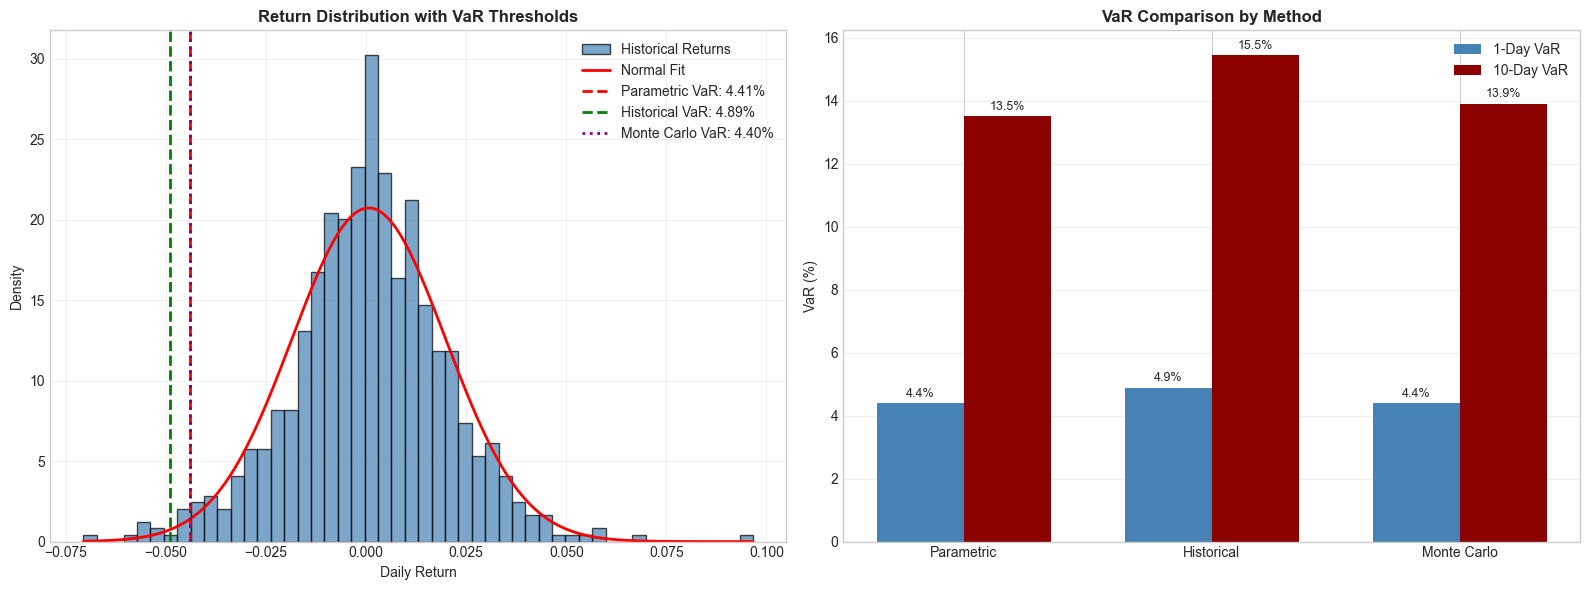

In [10]:
# Distribution comparison with VaR lines
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Historical returns vs Normal fit
ax1 = axes[0]
ax1.hist(train_returns, bins=50, density=True, alpha=0.7, color='steelblue', 
         edgecolor='black', label='Historical Returns')

# Normal distribution overlay
x = np.linspace(train_returns.min(), train_returns.max(), 1000)
ax1.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')

# VaR lines
ax1.axvline(param_var_1d, color='red', linestyle='--', linewidth=2, 
            label=f'Parametric VaR: {abs(param_var_1d):.2%}')
ax1.axvline(hist_var_1d, color='green', linestyle='--', linewidth=2, 
            label=f'Historical VaR: {abs(hist_var_1d):.2%}')
ax1.axvline(mc_var_1d, color='purple', linestyle=':', linewidth=2, 
            label=f'Monte Carlo VaR: {abs(mc_var_1d):.2%}')

ax1.set_title('Return Distribution with VaR Thresholds', fontsize=12, fontweight='bold')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Bar chart comparison
ax2 = axes[1]
methods = ['Parametric', 'Historical', 'Monte Carlo']
var_1d = [abs(param_var_1d), abs(hist_var_1d), abs(mc_var_1d)]
var_10d = [abs(param_var_10d), abs(hist_var_10d), abs(mc_var_10d)]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, [v*100 for v in var_1d], width, label='1-Day VaR', color='steelblue')
bars2 = ax2.bar(x_pos + width/2, [v*100 for v in var_10d], width, label='10-Day VaR', color='darkred')

ax2.set_ylabel('VaR (%)')
ax2.set_title('VaR Comparison by Method', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/02_var_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

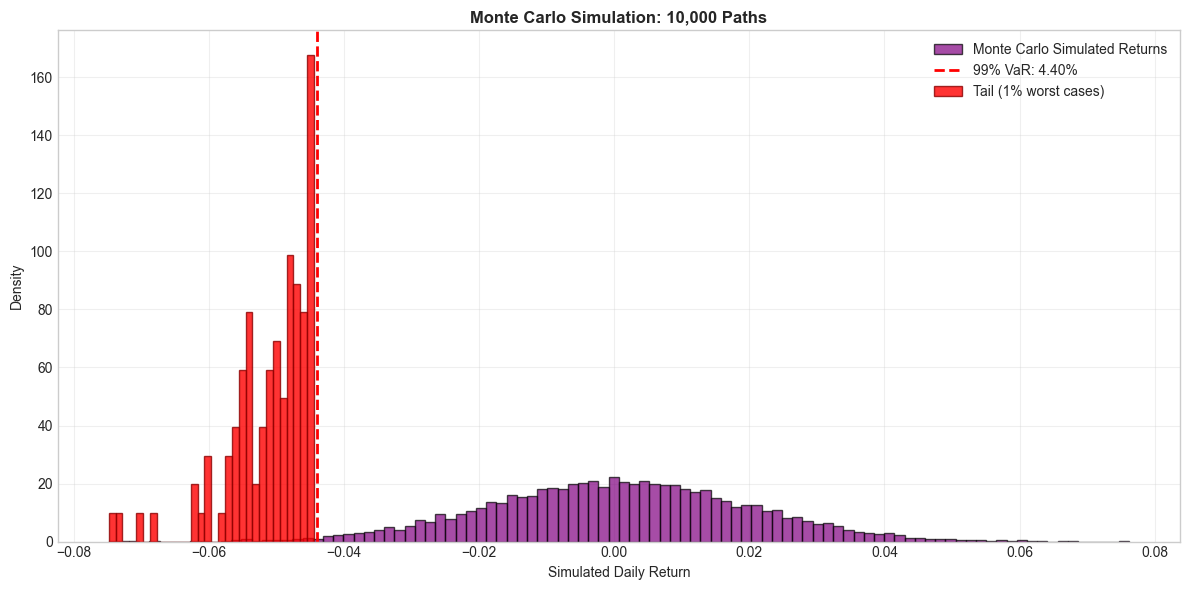

In [11]:
# Monte Carlo simulation distribution
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(simulated_returns, bins=100, density=True, alpha=0.7, color='purple', 
        edgecolor='black', label='Monte Carlo Simulated Returns')

# VaR threshold
ax.axvline(mc_var_1d, color='red', linestyle='--', linewidth=2, 
           label=f'99% VaR: {abs(mc_var_1d):.2%}')

# Shade the tail
tail_returns = simulated_returns[simulated_returns <= mc_var_1d]
ax.hist(tail_returns, bins=30, density=True, alpha=0.8, color='red', 
        edgecolor='darkred', label=f'Tail (1% worst cases)')

ax.set_title(f'Monte Carlo Simulation: {SIMULATIONS:,} Paths', fontsize=12, fontweight='bold')
ax.set_xlabel('Simulated Daily Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/02_monte_carlo_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.7 10-Day VaR: Square-Root-of-Time Rule

Basel regulations require a 10-day holding period for trading book capital. The square-root-of-time rule scales 1-day VaR:

$$VaR_{T-day} = VaR_{1-day} \times \sqrt{T}$$

### Assumptions
- Returns are i.i.d. (independently and identically distributed)
- Volatility is constant over the holding period

### Limitations
- May underestimate risk during volatility regimes
- Does not account for serial correlation

In [12]:
# Multi-period VaR scaling
holding_periods = [1, 5, 10, 21, 63, 252]  # 1-day, 1-week, 2-weeks, 1-month, 1-quarter, 1-year
period_names = ['1 Day', '1 Week', '2 Weeks', '1 Month', '1 Quarter', '1 Year']

scaled_var = pd.DataFrame({
    'Holding Period': period_names,
    'Days': holding_periods,
    'Parametric VaR': [abs(param_var_1d) * np.sqrt(t) for t in holding_periods],
    'Historical VaR': [abs(hist_var_1d) * np.sqrt(t) for t in holding_periods],
    'Monte Carlo VaR': [abs(mc_var_1d) * np.sqrt(t) for t in holding_periods]
})

# Format as percentages
for col in ['Parametric VaR', 'Historical VaR', 'Monte Carlo VaR']:
    scaled_var[col] = scaled_var[col].apply(lambda x: f"{x:.2%}")

display(Markdown("### VaR Scaling by Holding Period (Square-Root-of-Time Rule)"))
display(scaled_var)

### VaR Scaling by Holding Period (Square-Root-of-Time Rule)

,Holding Period,Days,Parametric VaR,Historical VaR,Monte Carlo VaR
0,1 Day,1,4.41%,4.89%,4.40%
1,1 Week,5,9.87%,10.94%,9.84%
2,2 Weeks,10,13.95%,15.47%,13.92%
3,1 Month,21,20.22%,22.41%,20.17%
4,1 Quarter,63,35.02%,38.82%,34.93%
5,1 Year,252,70.04%,77.64%,69.86%


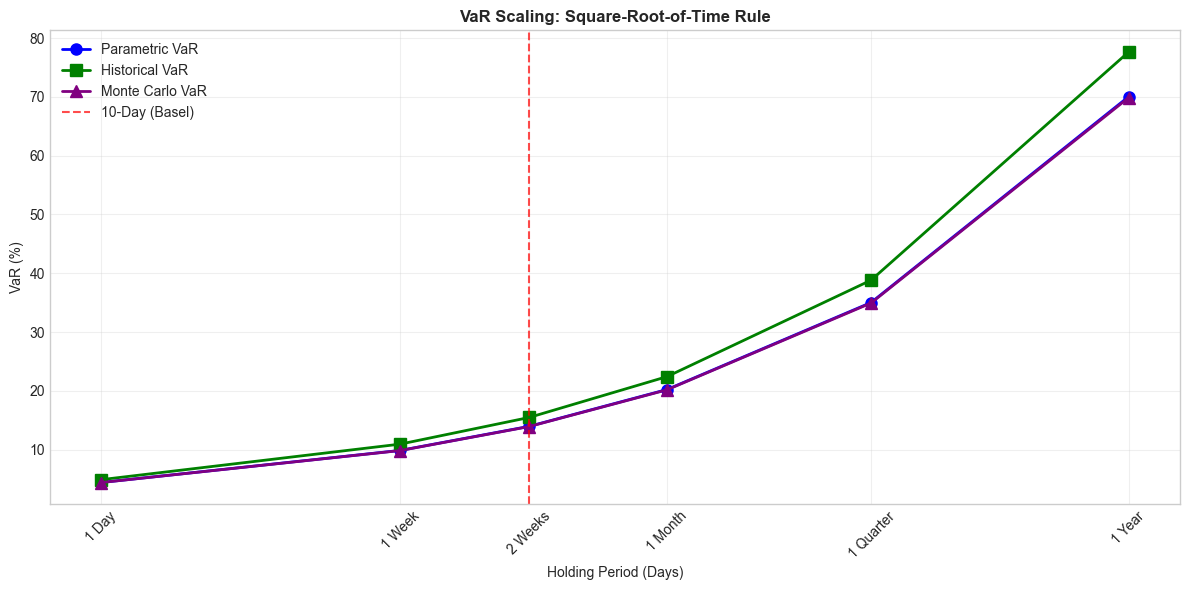

In [13]:
# Visualize VaR scaling
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(holding_periods, [abs(param_var_1d) * np.sqrt(t) * 100 for t in holding_periods], 
        'o-', linewidth=2, markersize=8, label='Parametric VaR', color='blue')
ax.plot(holding_periods, [abs(hist_var_1d) * np.sqrt(t) * 100 for t in holding_periods], 
        's-', linewidth=2, markersize=8, label='Historical VaR', color='green')
ax.plot(holding_periods, [abs(mc_var_1d) * np.sqrt(t) * 100 for t in holding_periods], 
        '^-', linewidth=2, markersize=8, label='Monte Carlo VaR', color='purple')

# Mark 10-day (Basel requirement)
ax.axvline(10, color='red', linestyle='--', alpha=0.7, label='10-Day (Basel)')

ax.set_xlabel('Holding Period (Days)')
ax.set_ylabel('VaR (%)')
ax.set_title('VaR Scaling: Square-Root-of-Time Rule', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_xticks(holding_periods)
ax.set_xticklabels(period_names, rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/02_var_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.8 Save Results

In [14]:
# Save VaR results for later notebooks
var_results = {
    'parametric': {
        'var_1d': param_var_1d,
        'var_10d': param_var_10d,
        'mu': mu,
        'sigma': sigma
    },
    'historical': {
        'var_1d': hist_var_1d,
        'var_10d': hist_var_10d
    },
    'monte_carlo': {
        'var_1d': mc_var_1d,
        'var_10d': mc_var_10d,
        'simulations': SIMULATIONS
    }
}

# Save to JSON
with open('../outputs/var_results.json', 'w') as f:
    json.dump(var_results, f, indent=4)

print("VaR results saved to outputs/var_results.json")

VaR results saved to outputs/var_results.json


---

## Summary

In this notebook, we implemented three VaR methodologies:

| Method | 1-Day 99% VaR | Key Characteristic |
|--------|---------------|--------------------|
| Parametric | Uses normal distribution | Fastest, may underestimate tail risk |
| Historical | Uses empirical distribution | Captures fat tails, limited by history |
| Monte Carlo | Simulates from fitted distribution | Flexible, computationally intensive |

**Key Findings:**
1. Historical VaR is often higher than Parametric VaR due to fat tails
2. The normal distribution assumption underestimates extreme losses
3. 10-day VaR (Basel requirement) is approximately 3.16x higher than 1-day VaR

**Next Steps:**
In Notebook 03, we will implement Expected Shortfall (ES/CVaR), which provides a more complete picture of tail risk and is required under Basel IV/FRTB.